In [ ]:

RANDOM_STATE = 42

def set_seeds(seed: int = 42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

set_seeds(RANDOM_STATE)

In [ ]:
# Load Dataset

import pandas as pd

DATA_PATH = "/content/foundation_dataset.csv"
df = pd.read_csv(DATA_PATH)


In [ ]:
#  Data Types

print(df.dtypes)

foundation_type     object
soil_condition      object
total_volume_m3    float64
labor_count          int64
duration_days        int64
dtype: object


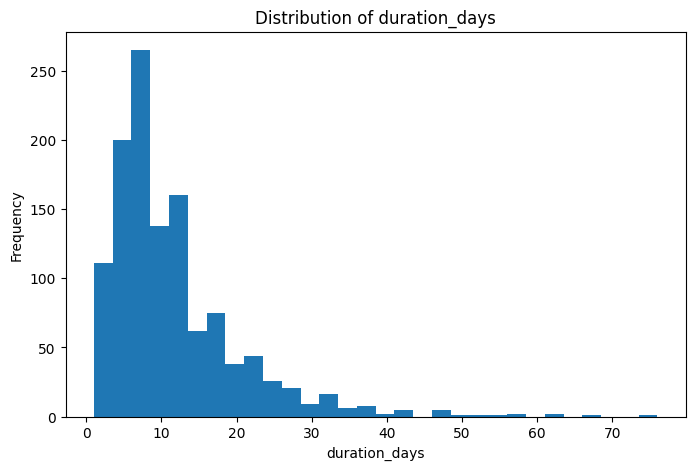

In [ ]:

#  Target Distribution


import matplotlib.pyplot as plt

TARGET_COL = "duration_Days" if "duration_Days" in df.columns else "duration_days"

plt.figure(figsize=(8, 5))
plt.hist(df[TARGET_COL], bins=30)
plt.title(f"Distribution of {TARGET_COL}")
plt.xlabel(TARGET_COL)
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Preprocessing (Missing values + Encoding + Scaling)

def split_features_target(df):
    target = "duration_Days" if "duration_Days" in df.columns else "duration_days"
    X = df.drop(columns=[target]).copy()
    y = df[target].copy()
    return X, y, target

def build_preprocessor(X, scale_numeric: bool):
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    num_pipe = Pipeline(steps=num_steps)

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols)
        ],
        remainder="drop"
    )
    return preprocessor

In [ ]:
#  Train/Test Split

from sklearn.model_selection import train_test_split

X, y, TARGET_COL = split_features_target(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(" Train:", X_train.shape, "| Test:", X_test.shape)

 Train: (960, 4) | Test: (240, 4)


In [ ]:
# Model Training Functions

# Linear Regression

def train_linear_regression(X_train, y_train):
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LinearRegression

    preprocessor = build_preprocessor(X_train, scale_numeric=True)
    model = LinearRegression()

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    return pipe


In [ ]:
# Random Forest Regressor

def train_random_forest(X_train, y_train, random_state=42):
    from sklearn.pipeline import Pipeline
    from sklearn.ensemble import RandomForestRegressor

    preprocessor = build_preprocessor(X_train, scale_numeric=False)
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1
    )

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    return pipe

In [ ]:
# XGBoost Regressor

def train_xgboost(X_train, y_train, random_state=42):
    from sklearn.pipeline import Pipeline
    from xgboost import XGBRegressor

    preprocessor = build_preprocessor(X_train, scale_numeric=False)
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=random_state,
        n_jobs=-1
    )

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    return pipe

In [ ]:
#  Train Models


lr_model = train_linear_regression(X_train, y_train)
rf_model = train_random_forest(X_train, y_train, random_state=RANDOM_STATE)
xgb_model = train_xgboost(X_train, y_train, random_state=RANDOM_STATE)

print(" All models trained successfully.")

 All models trained successfully.


In [ ]:

#  Model Evaluation Functions

import numpy as np

def regression_accuracy_10(y_true, y_pred, tolerance=0.10):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denom = np.where(y_true == 0, 1.0, y_true)
    rel_err = np.abs(y_pred - y_true) / np.abs(denom)

    return float(np.mean(rel_err <= tolerance))

def evaluate_model(name, model, X_test, y_test):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    acc = regression_accuracy_10(y_test, preds, tolerance=0.10)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Accuracy_±10%": acc
    }

In [ ]:

#  Evaluate All Models + Table


import pandas as pd

results = []
results.append(evaluate_model("Linear Regression", lr_model, X_test, y_test))
results.append(evaluate_model("Random Forest", rf_model, X_test, y_test))
results.append(evaluate_model("XGBoost", xgb_model, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("MAE", ascending=True)
display(results_df)

,Model,MAE,RMSE,R2,Accuracy_±10%
2,XGBoost,0.592629,1.147337,0.984085,0.854167
1,Random Forest,0.959958,1.900651,0.956325,0.729167
0,Linear Regression,2.577272,4.339881,0.772289,0.241667


In [ ]:

#  Best Model Selection (Lowest MAE)

best_row = results_df.iloc[0]
best_name = best_row["Model"]

best_model = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}[best_name]

print(" Best Model:", best_name)
print("MAE:", best_row["MAE"])
print("RMSE:", best_row["RMSE"])
print("R²:", best_row["R2"])
print("Accuracy (±10%):", best_row["Accuracy_±10%"])

 Best Model: XGBoost
MAE: 0.5926291346549988
RMSE: 1.1473367826781953
R²: 0.9840848445892334
Accuracy (±10%): 0.8541666666666666


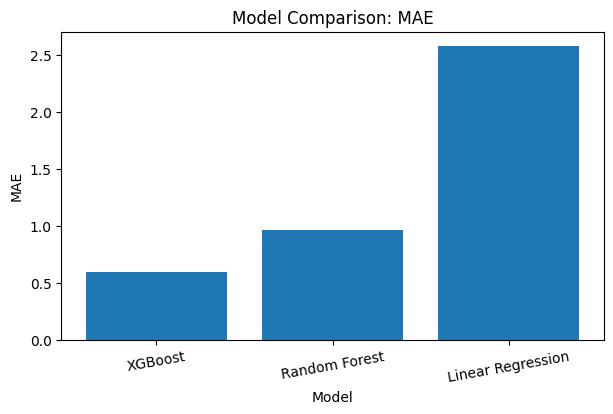

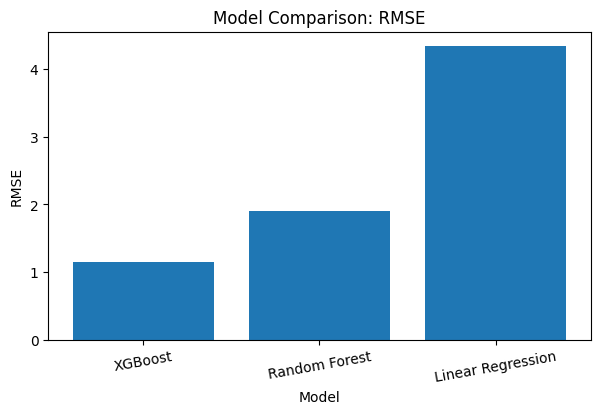

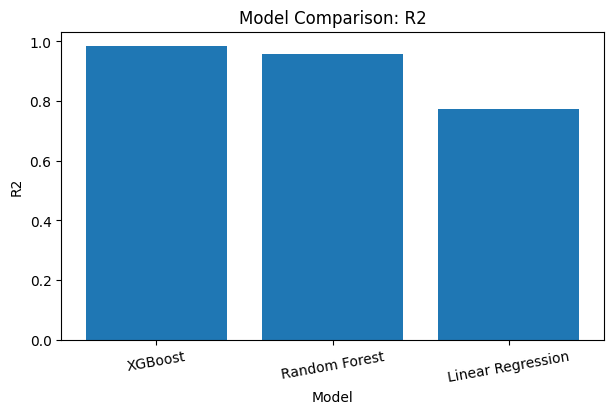

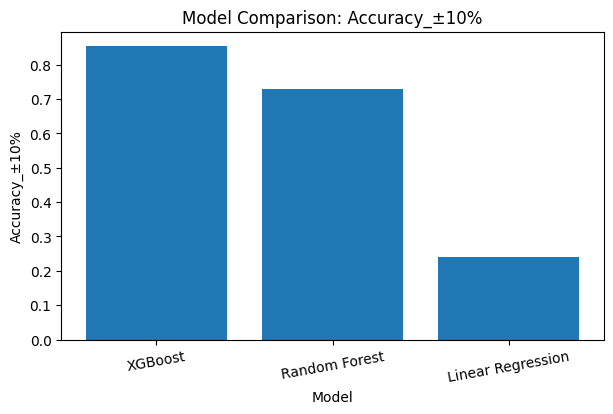

In [ ]:

#  Model Comparison Bar Charts


metrics = ["MAE", "RMSE", "R2", "Accuracy_±10%"]

for metric in metrics:
    plt.figure(figsize=(7, 4))
    plt.bar(results_df["Model"], results_df[metric])
    plt.title(f"Model Comparison: {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=10)
    plt.show()

In [ ]:

#  Save Best Model Pipeline

import joblib

SAVE_PATH = "foundation_pipeline.pkl"
joblib.dump(best_model, SAVE_PATH)

print(f" Saved pipeline to: {SAVE_PATH}")

 Saved pipeline to: foundation_pipeline.pkl


In [ ]:

#  Load Saved Model

import joblib
import pandas as pd

loaded_model = joblib.load("foundation_pipeline.pkl")

new_input = pd.DataFrame([{

    "foundation_type": "Pile",
    "soil_condition": "Normal",
    "total_volume_m3": 55,
    "working_hours_per_day": 8,
    "labor_count": 10
}])

pred = loaded_model.predict(new_input)[0]

print(" New Input:")
display(new_input)

print(f" Predicted Duration_Days: {pred:.0f} days")

 New Input:


,foundation_type,soil_condition,total_volume_m3,working_hours_per_day,labor_count
0,Pile,Normal,55,8,10


 Predicted Duration_Days: 12 days
